In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import f_oneway
# import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
# import the functions to perform Chi-square tests
from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chisquare

In [2]:
import os
os.getcwd()

'C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking'

Exploratory Data Analysis & Descriptive Statistics

1. Basic Summary statistics of the data for the numerical variables
2. basic Summary of the data for the number of working days, count of quarters in the year
3. Mean and standard deviation of actual producivity for every quarter and Histogram plot of actual productivity based on every quarter and conclusion accordingly
4. Number count for sewing and finishing department
5. Mean and standard deviation of actual producivity for sewing and finishing Histogram plot of actual productivity based on both department and conclusion accordingly
6. Number count for  teams, smv across the year
7. Histogram & Box plot of actual productivity based on all working days, team size, quarterts and  Conclude accordingly
8. Find correlation matrix and draw heat map for all variables
9. Conclude (Is the company able to meet target, are they giving incentives based on producitivity, does overtime have any effect on productivity)
10. Find the correlation between actual and target productivity for every quarter and for every department. What do you conclude
11. Based on the above details of EDA and Descriptive statisitcs analysis what would you say could be the possible factors which can affect producitivity.

In [2]:
garments = pd.read_csv("C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\garments_worker_productivity.csv")
garments.head(10).T

,0,1,2,3,4,5,6,7,8,9
date,01-01-2015,01-01-2015,01-01-2015,01-01-2015,01-01-2015,01-01-2015,01-01-2015,01-01-2015,01-01-2015,01-01-2015
quarter,Quarter1,Quarter1,Quarter1,Quarter1,Quarter1,Quarter1,Quarter1,Quarter1,Quarter1,Quarter1
department,sewing,finishing,sewing,sewing,sewing,sewing,finishing,sewing,sewing,sewing
day,Thursday,Thursday,Thursday,Thursday,Thursday,Thursday,Thursday,Thursday,Thursday,Thursday
team,8,1,11,12,6,7,2,3,2,1
targeted_productivity,0.8,0.75,0.8,0.8,0.8,0.8,0.75,0.75,0.75,0.75
smv,26.16,3.94,11.41,11.41,25.9,25.9,3.94,28.08,19.87,28.08
wip,1108.0,NaN,968.0,968.0,1170.0,984.0,NaN,795.0,733.0,681.0
over_time,7080,960,3660,3660,1920,6720,960,6900,6000,6900
incentive,98,0,50,50,50,38,0,45,34,45


In [63]:
#1.Basic Summary statistics of the data for the numerical variables
numerical_variables = garments.describe(include = 'int')
numerical_variables


,team,over_time,incentive,idle_men,no_of_style_change
count,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,4567.460317,38.210526,0.369256,0.150376
std,3.463963,3348.823563,160.182643,3.268987,0.427848
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1440.000000,0.000000,0.000000,0.000000
50%,6.000000,3960.000000,0.000000,0.000000,0.000000
75%,9.000000,6960.000000,50.000000,0.000000,0.000000
max,12.000000,25920.000000,3600.000000,45.000000,2.000000


In [64]:
#2.Basic Summary of the data for the number of working days, count of quarters in the year
garments.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

In [54]:
noof_workingdays= garments['day'].value_counts()
noof_workingdays

day
Wednesday    208
Sunday       203
Tuesday      201
Thursday     199
Monday       199
Saturday     187
Name: count, dtype: int64

In [55]:
count_of_quarters=garments['quarter'].value_counts()
count_of_quarters
#ignore q5

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64

quarter
Quarter1    0.751560
Quarter2    0.743710
Quarter3    0.704759
Quarter4    0.709067
Quarter5    0.826177
Name: actual_productivity, dtype: float64


Text(0.5, 1.0, ' Mean Actual  productivity for every quarter')

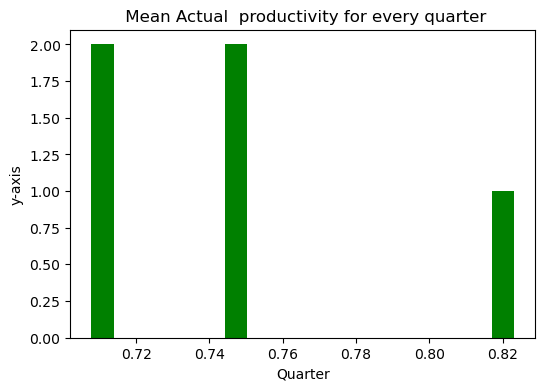

In [65]:
#3.Mean and standard deviation of actual producivity for every quarter and Histogram plot of actual productivity based on every quarter and conclusion accordingly
means_of_quarters=garments.groupby('quarter')['actual_productivity'].agg('mean')
plt.figure(figsize=(6,4))
plt.hist(means_of_quarters, orientation='vertical',label='quarter',color='green',  rwidth=0.5)
print(means_of_quarters)
plt.xlabel('Quarter')
plt.ylabel('y-axis')
plt.title(' Mean Actual  productivity for every quarter')



quarter
Quarter1    0.161318
Quarter2    0.171114
Quarter3    0.175614
Quarter4    0.185983
Quarter5    0.183851
Name: actual_productivity, dtype: float64


Text(0.5, 1.0, ' Standard Deviation of  Actual  productivity for every quarter')

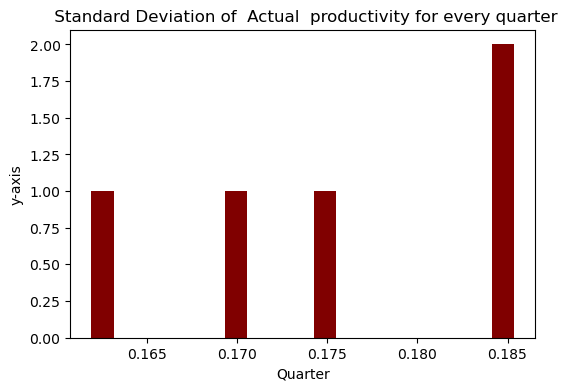

In [10]:
stddev_of_quarters=garments.groupby('quarter')['actual_productivity'].agg('std')
plt.figure(figsize=(6,4))
plt.hist(stddev_of_quarters, orientation='vertical',label='quarter',color='maroon',  rwidth=0.5)
print(stddev_of_quarters)
plt.xlabel('Quarter')
plt.ylabel('y-axis')
plt.title(' Standard Deviation of  Actual  productivity for every quarter')

In [8]:
#4.Number count for sewing and finishing department
garments.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

In [75]:
#Extract no of workers based on team
sewing_department=garments[garments['department']=='sewing']['team'].value_counts()
print("No of workers in sewing_department \n",sewing_department)
finishing_department = garments[garments['department'] == 'finishing']['team'].value_counts()
print("No of workers in finishing_department \n ",finishing_department)

No of workers in sewing_department 
 team
11    59
12    59
6     59
4     59
3     58
9     58
5     58
2     57
10    57
8     56
1     56
7     55
Name: count, dtype: int64
No of workers in finishing_department 
  team
8     53
2     52
1     49
4     46
9     46
10    43
7     41
12    40
3     37
5     35
6     35
11    29
Name: count, dtype: int64


In [96]:
#5.Mean and standard deviation of actual producivity for sewing and finishing Histogram plot of actual productivity based on both department and conclusion accordingly
mean_actual_productivity_sewing = garments[garments.department=='sewing']['actual_productivity'].agg('mean')
stddev_actual_productivity_sewing = garments[garments.department=='sewing']['actual_productivity'].agg('std')
print(" Mean of actual productivity of sewing department",np.round(mean_actual_productivity_sewing,3))
print("Standard Deviation of actual productivity of sewing department \n ",np.round(stddev_actual_productivity_sewing ,3))

print("\n----------")
mean_actual_productivity_finishing = garments[garments.department=='finishing']['actual_productivity'].agg('mean')
stddev_actual_productivity_finishing = garments[garments.department=='finishing']['actual_productivity'].agg('std')
print(" Mean of actual productivity of finishing department",np.round(mean_actual_productivity_finishing ,3))
print("Standard Deviation of actual productivity of finishing department \n",np.round(stddev_actual_productivity_finishing,3))
sewing=[]
sewing.append([mean_actual_productivity_sewing,stddev_actual_productivity_sewing])
finishing=[]
finishing.append([mean_actual_productivity_finishing,stddev_actual_productivity_finishing])




 Mean of actual productivity of sewing department 0.722
Standard Deviation of actual productivity of sewing department 
  0.155

----------
 Mean of actual productivity of finishing department 0.753
Standard Deviation of actual productivity of finishing department 
 0.197


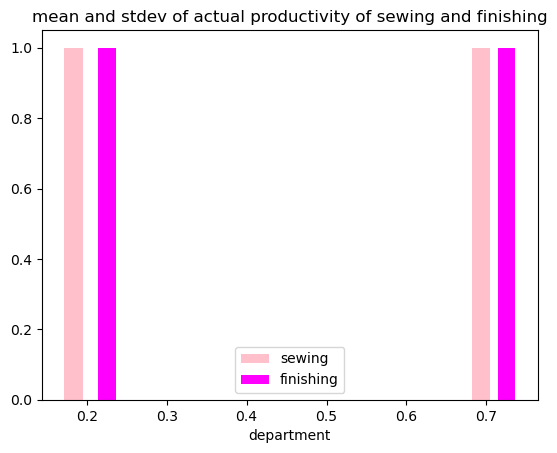

In [154]:
#Histogram plot of actual productivity based on both department
plt.hist(x=sewing,rwidth=0.4,color='pink' ,label = 'sewing')
plt.hist(x=finishing,rwidth=0.4,color='magenta',label='finishing')
plt.xlabel('department')
plt.title("mean and stdev of actual productivity of sewing and finishing")
plt.legend()
plt.show()



<Axes: xlabel='actual_productivity', ylabel='Count'>

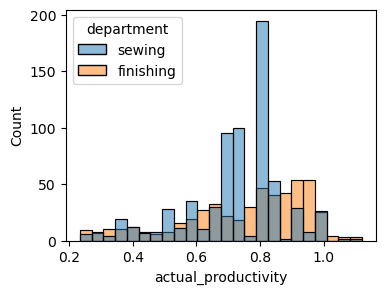

In [164]:
#histogram plot of actual productivity based on department
plt.figure(figsize=(4,3), dpi=100)
sns.histplot(x=garments.actual_productivity,hue=garments.department)

In [ ]:
#conclusion
1. The Finishing department has better productivity than sewing department
2. The Finishing department has more std dev than sewing department. This shows that the difference in max and min productivity in sewing department is lesser than in finishing department. 

In [172]:
#6.Number count for teams, smv across the year
team_smv=garments.groupby(garments.quarter)[['team','smv']].value_counts()
print("Number count for teams, smv across the year\n",team_smv)

Number count for teams, smv across the year
 quarter   team  smv  
Quarter1  1     3.94     18
          12    15.26    12
          4     3.94     11
          2     3.94     10
          6     2.90      9
                         ..
Quarter5  8     4.15      1
                23.54     1
          9     3.94      1
          11    2.90      1
                3.94      1
Name: count, Length: 328, dtype: int64


histogram grouped by day 

histogram grouped by team 

histogram grouped by quarter 



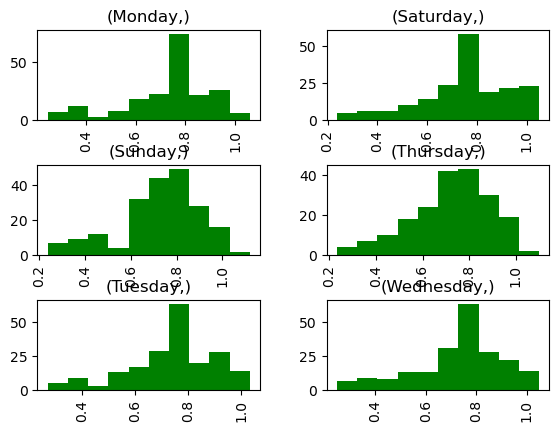

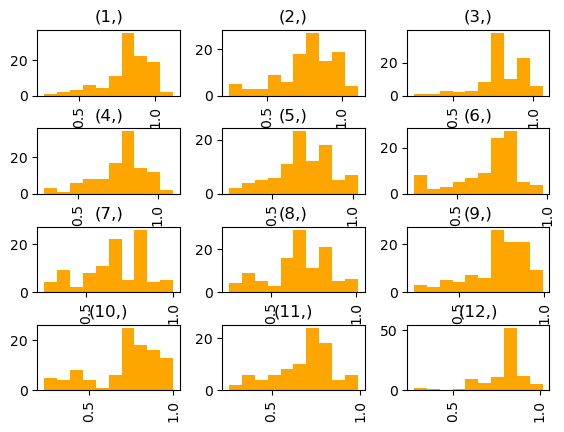

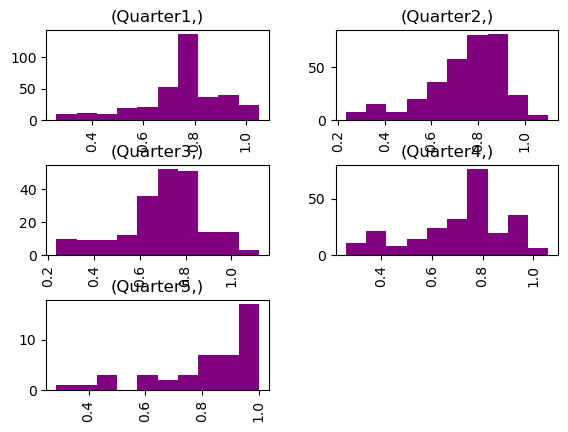

In [68]:
#7.Histogram & Box plot of actual productivity based on all working days, team size, quarterts and Conclude accordingly
print("histogram grouped by day \n")
garments.hist(['actual_productivity'],by=['day'],color='green')
print("histogram grouped by team \n")
garments.hist(['actual_productivity'],by=['team'],color='orange')
print("histogram grouped by quarter \n")
garments.hist(['actual_productivity'],by=['quarter'],color='purple')
plt.show()

In [ ]:
#conclusion based on days and team
1. More workers are showing same productivity (concentrated around .8) on Mondays than any other days.
2. More Workers are showing equally likely productivity on sundays(.7 to .85) and thursdays (.7 to .9)
3. Team 12 workers show similar productivity 
4. Team 9 and 10 have large number of high productive workers. 
5. Q5 is most productive 
6. Q1 - more number of workers show same productivity
7. Q2 - equal distribution of workers seen in the productivity range (.8 - .9)


Box plot of actual productivity based on all working days


C:\Users\Chidi\AppData\Local\Temp\ipykernel_2452\34370004.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=garments.actual_productivity,x=garments.day,palette='bright')


<Axes: xlabel='day', ylabel='actual_productivity'>

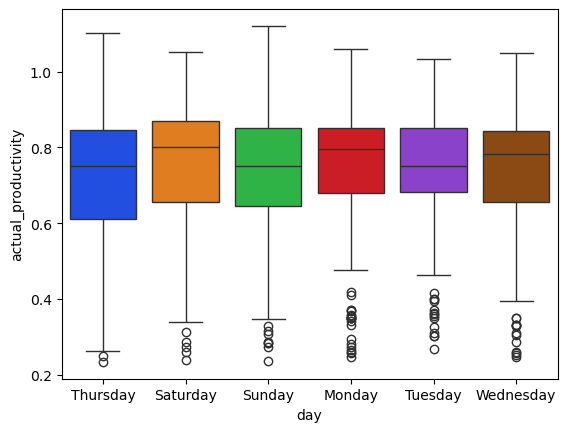

In [138]:
print("Box plot of actual productivity based on all working days")
sns.boxplot(y=garments.actual_productivity,x=garments.day,palette='bright')




In [ ]:
#Conclusions
1. Less outliers on Thursday mean, maximum of the workers are showing similar productivity
2. Excluding the outliers on sunday, more workers are showing similar productivity distributed more or less equally in the range of 0.65 to 0.85
3. On mondays and tuesdays, lot of workers productivity is very less as they have lot of outliers
5. Thursdays show longtails as they are left skewed and has the minimum  outliers  
6. Sunday shows more productivity and is consistent

Box plot of actual productivity based on  team


C:\Users\Chidi\AppData\Local\Temp\ipykernel_2452\633620840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=garments.actual_productivity,x=garments.team,palette='bright')


<Axes: xlabel='team', ylabel='actual_productivity'>

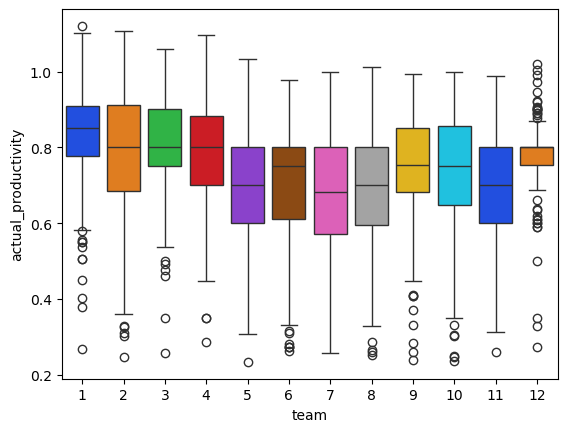

In [139]:
print("Box plot of actual productivity based on  team")
sns.boxplot(y=garments.actual_productivity,x=garments.team,palette='bright')


In [ ]:
#Conclusions
1. Team 5 and 11 have most workers with similar productivity with average productivity of around 0.7
2. Team  7 has no outliers the  productivity distribution seems symmetric 
3. Team12 has  more number of outliers on both sides and with productivity around 0.8 
4. Team 1,6 are negatively skewed
5. Team 3,9 are positively skewed

Box plot of actual productivity based on all quarters


C:\Users\Chidi\AppData\Local\Temp\ipykernel_2452\3952370038.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=garments.actual_productivity,x=garments.quarter,palette='bright')


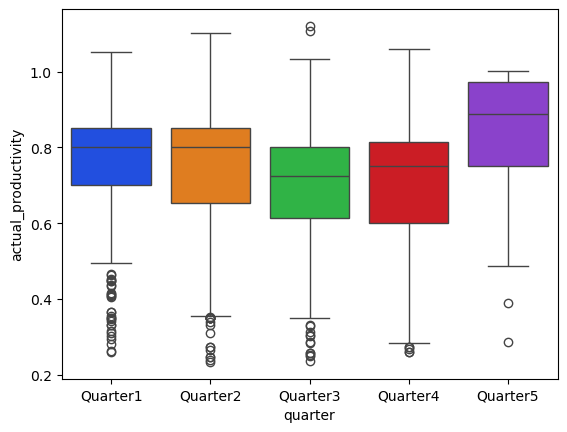

In [140]:
print("Box plot of actual productivity based on all quarters")
sns.boxplot(y=garments.actual_productivity,x=garments.quarter,palette='bright')
plt.show()

In [ ]:
#Conclusions
1. Q3 has outliers on both sides with mean productivity of 0.7
2. Q1  is negatively skewed with outliers with mean productivity of 0.8
3. Q2 is negatively skewed with  outliers in the lower quartile with mean productivity of 0.8
4. Q4 has three outliers with mean productivity of 0.78
5. Q5 has least outliers with highest mean productivity 

In [75]:
#8.Find correlation matrix and draw heat map for all variables
garments_corr=garments.corr(numeric_only = True)
garments_corr

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
team,1.000000,0.030274,-0.110011,-0.033474,-0.096737,-0.007674,0.003796,0.026974,-0.011194,-0.075113,-0.148753
targeted_productivity,0.030274,1.000000,-0.069489,0.062054,-0.088557,0.032768,-0.056181,-0.053818,-0.209294,-0.084288,0.421594
smv,-0.110011,-0.069489,1.000000,-0.037837,0.674887,0.032629,0.056863,0.105901,0.315388,0.912176,-0.122089
wip,-0.033474,0.062054,-0.037837,1.000000,0.022302,0.167210,-0.026299,-0.048718,-0.072357,0.030383,0.131147
over_time,-0.096737,-0.088557,0.674887,0.022302,1.000000,-0.004793,0.031038,-0.017913,0.059790,0.734164,-0.054206
incentive,-0.007674,0.032768,0.032629,0.167210,-0.004793,1.000000,-0.012024,-0.021140,-0.026607,0.049222,0.076538
idle_time,0.003796,-0.056181,0.056863,-0.026299,0.031038,-0.012024,1.000000,0.559146,-0.011598,0.058049,-0.080851
idle_men,0.026974,-0.053818,0.105901,-0.048718,-0.017913,-0.021140,0.559146,1.000000,0.133632,0.106946,-0.181734
no_of_style_change,-0.011194,-0.209294,0.315388,-0.072357,0.059790,-0.026607,-0.011598,0.133632,1.000000,0.327787,-0.207366
no_of_workers,-0.075113,-0.084288,0.912176,0.030383,0.734164,0.049222,0.058049,0.106946,0.327787,1.000000,-0.057991


<Axes: >

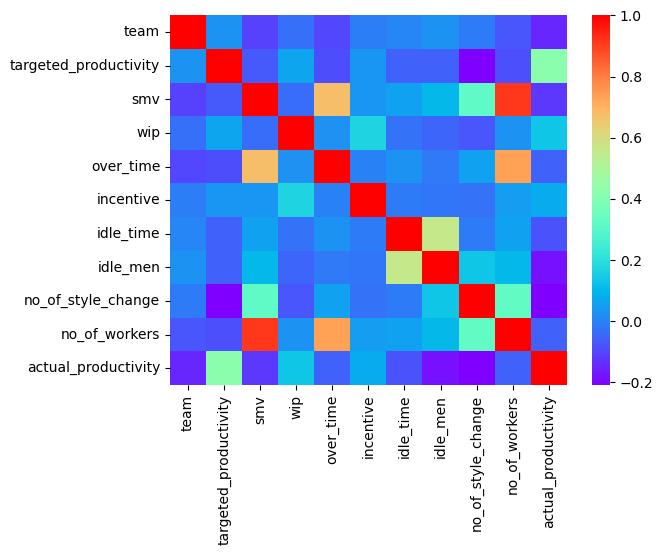

In [142]:
sns.heatmap(garments_corr,cmap='rainbow')

In [ ]:
#9.Conclude (Is the company able to meet target, are they giving incentives based on producitivity, does overtime have any effect on productivity)

<Axes: xlabel='actual_productivity', ylabel='targeted_productivity'>

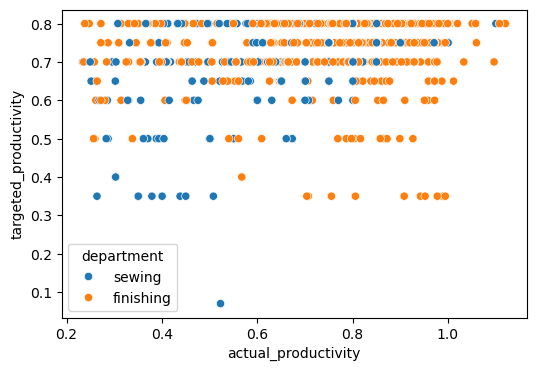

In [97]:
#Is the company able to meet target
plt.figure(figsize=(6,4),dpi=100)
sns.scatterplot(x=garments.actual_productivity ,y=garments.targeted_productivity , hue =garments.department)


In [ ]:
#conclusion 
1.The company is able to meet their target productivity and workers actualproductivity exceeds target 
2.Finishing department acheives its target and the productivity is more likely than sewing department
3.The average productivity shows in between 0.7 to 0.8

<Axes: xlabel='incentive', ylabel='actual_productivity'>

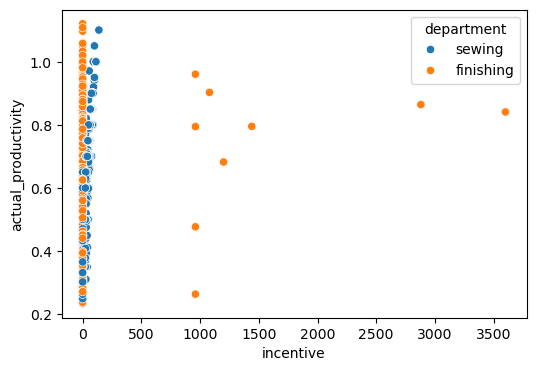

In [11]:
#are they giving incentives based on producitivity
plt.figure(figsize=(6,4), dpi=100)
sns.scatterplot(y=garments.actual_productivity,x=garments.incentive,hue=garments.department)

In [ ]:
#conclusion
1.finishing department receives almost  no incentives based on productivity 
2.Sewing department recieves more  incentives than finishing department

<Axes: xlabel='over_time', ylabel='actual_productivity'>

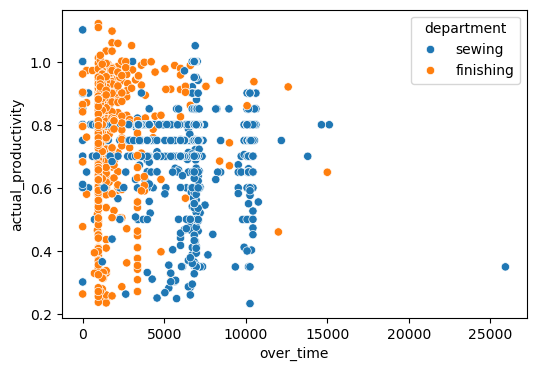

In [88]:
#does overtime have any effect on productivity
plt.figure(figsize=(6,4), dpi=100)
sns.scatterplot(x=garments.over_time, y=garments.actual_productivity,hue=garments.department)

In [ ]:
#conclusion
1.Overtime has effect on productivity for both departments
2.Sewing department seems to have worked for more time than finishing department in between 3000 to 10000
3.Finishing department has  worked in between 0 to 4000 which is comparetively lesser time than sewing 

In [ ]:
#10.Find the correlation between actual and target productivity for every quarter and for every department. What do you conclude

In [114]:
#correlation between actual and target productivity for every quarter
quarter_based_correlation=garments.groupby(garments.quarter)['actual_productivity'].corr(garments['targeted_productivity'])
quarter_based_correlation


quarter
Quarter1    0.492779
Quarter2    0.427164
Quarter3    0.392637
Quarter4    0.347594
Quarter5    0.479972
Name: actual_productivity, dtype: float64

In [ ]:
#Conclusion:
1.The observed productivity seen among Q1,Q2,Q5 are more likely  above 40% towards productivity .
2.Q3 and Q4 have shown their productivity lesser than 40%

In [117]:
#correlation between actual and target productivity for every  department
deparment_based_correlation=garments.groupby(garments.department)['actual_productivity'].corr(garments['targeted_productivity'])
deparment_based_correlation

department
finishing    0.09751
sewing       0.69797
Name: actual_productivity, dtype: float64

In [ ]:
#conclusion:
1.sewing department attains actual and its targeted  productivity more than finishing department

In [ ]:
#11.Based on the above details of EDA and Descriptive statisitcs analysis what would you say could be the possible factors which can affect producitivity.
#conclusions
Factors which affect productivity
1.Lesser or no Incentives for finishing department  based on actual productivity
2.Overtime based incentives
3.Target based incentives 


Hypothesis Testing

12. Test using Z test (take a random sample of more than 30 and assume sigma =.1) whether the finishing department has achieved more acheived producitivity than .75 for a standard deviation of .1. State your null and alternative hypothesis. alpha value is .05

13. Test using Z test(take a random sample of more than 30 and assume sigma =.1) whether the sewing department has achieved more producitivit than .75 for a standard deviation of .1. State your null and alternative hypothesis. alpha value is .05.

14. Conduct a two sample t test (take a random sample more than 30) to check whether the finishing department has achieved more actual productivtiy than sewing     department. State your null and alternative hypothesis

15. Conduct a two sample t (take a random sample less than 30) test to check whether the finishing department has achieved obtained higher incentive than sewing department, state your null and alternative hypothesis. In case test fails for normality check, then take a sample more than 30.

16. The manager has asked you to classifiy low productivity as less than .5, medium between .5 and less than .75 and higher
    as greater than or equal to .75. He believes that the percentage of  actual producvity  in  sewing departemnt for   
    person classified as low is 30%, for medium is 40% and for high is 30%. USing chi square test can you prove whether his
    hypothesis is right or not

17. Based on the EDA analysis the manager has decided to find out whether different quarters are having an impact on actual productivity. Assuming normality of data conduct an analysis accordingly Conduct an ANOVA for comparing productivity for Quarter1, Quarter2, Quarter3, Quarter 4 and accordingly conclude (Assume data is normally distributed)

18. In case the manager is interested whether day and quarters have an impact on actual producitivity, provide an analysis and identify which factors play a role in affecting productivty

19. Based on 17 eliminate one of the variabes which is not significant and reconduct analysis using deparment as another variable, what do you conclude.

20. Based on EDA and Hypothesis would you aggree or disaggree with the finding, also in addition summarize the findings based on both analysis and provide a recommendation on what you can thinking on improving the producitivity.


# 12.Test using Z test (take a random sample of more than 30 and assume sigma =.1) 
# whether the finishing department has achieved more acheived producitivity than .75
# for a standard deviation of .1. State your null and alternative hypothesis. alpha value is .05



In [ ]:
#State null and alternative hypothesis
#H0 : finishingdept_productivity  mu <= .75
#H1 : finishingdept_productivity   mu > .75

In [6]:
mu = .75

In [7]:
# Level of significance (5%)
alpha=0.05 

In [ ]:
# find the test statistic from the sample data
#ztest_stat = (xbar -mu )  /  (sigma / sqrt(n))

In [36]:
#Mean for actual productivity for sewing ,finishing departments
finishing_dept_mean , sewing_dept_mean =garments.groupby(garments.department)['actual_productivity'].mean()
print('finishing_dept_mean',finishing_dept_mean)
print('sewing_dept_mean',sewing_dept_mean)


finishing_dept_mean 0.7529506683241107
sewing_dept_mean 0.7220130317105644


In [37]:
#Basic statistics for actualproductivity  group by departments
garments.groupby(garments.department)['actual_productivity'].describe()

,count,mean,std,min,25%,50%,75%,max
department,,,,,,,,
finishing,506.0,0.752951,0.197021,0.235795,0.631606,0.805909,0.906364,1.120437
sewing,691.0,0.722013,0.154784,0.233705,0.661470,0.750608,0.800402,1.100484


In [40]:
#Extracting count for sewing and finishing departments
finishing_dept_count,sewing_dept_count=garments.groupby(garments.department)['actual_productivity'].count()
print("finishing_dept_count",finishing_dept_count)
print("sewing_dept_count",sewing_dept_count)

finishing_dept_count 506
sewing_dept_count 691


In [45]:
#perform z_stat
xbar=finishing_dept_mean
n=finishing_dept_count
sigma = .1 
std_error=sigma / np.sqrt(n)
z_stat = (xbar - mu) / std_error
z_stat

0.6637364266641291

In [43]:
#find the critical values and compare test statisitc ; establish critical region
import scipy.stats as st
zalphaby2=st.norm.isf(alpha/2)
zalphaby2

1.9599639845400545

In [46]:
#Decision making or infering on population: p_value approach
pvalue=st.norm.cdf(z_stat) * 2
pvalue

1.4931409791632082

In [48]:
#conclusion
pvalue=st.norm.cdf(z_stat) * 2
print("pvalue",pvalue)
alpha=0.05
if pvalue < alpha:
    print("\n Reject H0.The Finishing department has acheived less productivity than  .75")
else:
    print("\n Fail to Reject H1.The Finishing department has acheived more  productivity than  .75")

pvalue 1.4931409791632082

 Fail to Reject H1.The Finishing department has acheived more  productivity than  .75


# 13.Test using Z test(take a random sample of more than 30 and assume sigma =.1) 
# whether the sewing department has achieved more producitivit than .75 for a standard deviation of .1. 
# State your null and alternative hypothesis. alpha value is .05.

In [ ]:
#State Null and Alternate Hypothesis
#H0: sewing_dept_productivity  mu <= .75
#H1 : sewing_dept_productivity   mu > .75

In [33]:
mu = .75

In [34]:
#level of significance  at 5 %
alpha=0.05

In [ ]:
#perform z test
#sewing_z_stat = (xbar - mu) / (sigma / sqrt(n))

In [35]:
#Extract mean 
finishing_dept_mean , sewing_dept_mean =garments.groupby(garments.department)['actual_productivity'].mean()
print('finishing_dept_mean',finishing_dept_mean)
print('sewing_dept_mean',sewing_dept_mean)

finishing_dept_mean 0.7529506683241107
sewing_dept_mean 0.7220130317105644


In [37]:
#Extract  count for finishing and sewing departments
finishing_dept_count,sewing_dept_count=garments.groupby(garments.department)['actual_productivity'].count()
print("finishing_dept_count",finishing_dept_count)
print("sewing_dept_count",sewing_dept_count)

finishing_dept_count 506
sewing_dept_count 691


In [39]:
#compute z_stats

xbar=sewing_dept_mean
n=sewing_dept_count
sigma = .1
sewing_std_err=  sigma / np.sqrt(n) 
sewing_z_stats= ( xbar - mu ) / sewing_std_err
sewing_z_stats

-7.356900449764196

In [40]:
#Find the critical values and compare test statitics ; establish critical region
import scipy.stats as st
zalphaby2=st.norm.isf(alpha / 2)
zalphaby2

1.9599639845400545

In [41]:
#Decision making infering on population ,p_value approach
pvalue_sew=st.norm.cdf(sewing_z_stats) * 2
pvalue_sew

1.882296145182603e-13

In [44]:
#conclusion
pvalue_sew=st.norm.cdf(sewing_z_stats) * 2
pvalue_sew
print("pvalue",pvalue_sew)
alpha=0.05
if pvalue < alpha:
    print("\n Reject H0.The Sewing department has acheived less productivity than  .75")
else:
    print("Fail to Reject H1.The Sewing department has acheived more  productivity than  .75")

pvalue 1.882296145182603e-13

 Reject H0.The Sewing department has acheived less productivity than  .75


# 14.Conduct a two sample t test (take a random sample more than 30) to check 
# whether the finishing department has achieved more actual productivtiy than sewing department. 
# State your null and alternative hypothesis

In [5]:
#Basic statistics of actualproductivity based on departments
garments.groupby(garments.department)['actual_productivity'].describe()


,count,mean,std,min,25%,50%,75%,max
department,,,,,,,,
finishing,506.0,0.752951,0.197021,0.235795,0.631606,0.805909,0.906364,1.120437
sewing,691.0,0.722013,0.154784,0.233705,0.661470,0.750608,0.800402,1.100484


In [ ]:
#State Null hypothesis and alternate hypothesis 
H0 : finishing_dept_actual_productivity >  sewing_dept_actual_productivity
H1 : finishing_dept_actual_productivity <=  sewing_dept_actual_productivity



In [ ]:
# level of significance at 5%
alpha= 0.05

In [23]:
#Since both are independent samples and the population variance is unknown ,choosing 2 sample t test
import scipy.stats as st


In [25]:
#Extract actualproductivity for finishing and sewing departments 
finishing_actual_productivity=garments[garments.department  == 'finishing']['actual_productivity']
sewing_actual_productivity=garments[garments.department == 'sewing']['actual_productivity']


sewing_actual_productivity


C:\Users\Chidi\AppData\Local\Temp\ipykernel_4588\1911252025.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sewing_actual_productivity,label='sewing')


<Axes: xlabel='actual_productivity', ylabel='Density'>

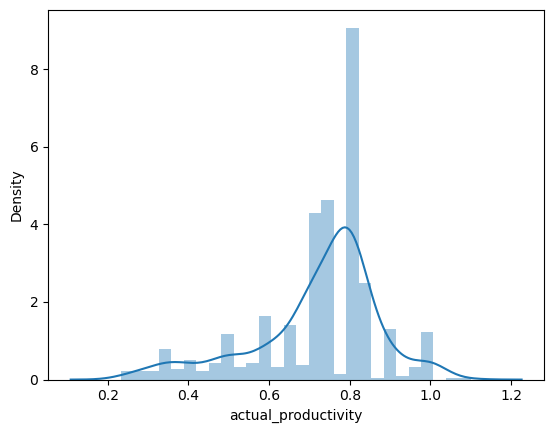

In [19]:
#Visualsing actualproductivity for sewing
sns.distplot(sewing_actual_productivity,label='sewing')

C:\Users\Chidi\AppData\Local\Temp\ipykernel_4228\4081377502.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(finishing_actual_productivity,label='finishing')


<Axes: xlabel='actual_productivity', ylabel='Density'>

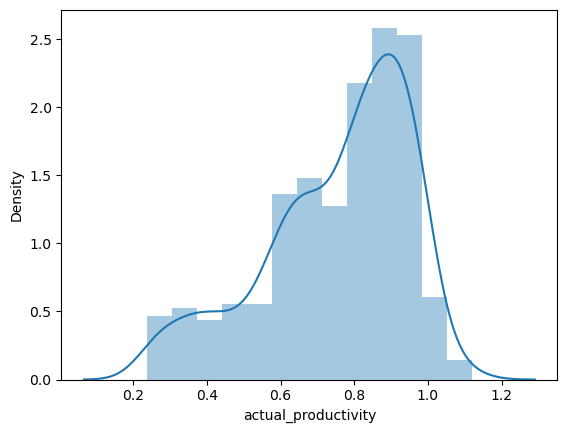

In [27]:
#Visualsing actualproductivity for finishing
sns.distplot(finishing_actual_productivity,label='finishing')

In [28]:
#ttest for 2 independent samples
ttest_2sample=st.ttest_ind(finishing_actual_productivity , sewing_actual_productivity,alternative = 'greater')
ttest_2sample

TtestResult(statistic=3.040752443283168, pvalue=0.0012056299888119192, df=1195.0)

In [ ]:
H0 : finishing_dept_actual_productivity >  sewing_dept_actual_productivity
H1 : finishing_dept_actual_productivity <=  sewing_dept_actual_productivity


In [31]:

#conclusion
ttstatitics,pvalue = st.ttest_ind(finishing_actual_productivity , sewing_actual_productivity,alternative = 'greater')
print("ttstatitics",ttstatitics)
print("pvalue",pvalue)
alpha=0.05
if pvalue < alpha:
    print("\n Reject H0.Finishing department's actual_productivity is more than the sewing department's actual_productivity")
else:
    print("Fail to Reject H1.Finishing department's actual_productivity is lesser  than the sewing department's actual_productivity")

ttstatitics 3.040752443283168
pvalue 0.0012056299888119192

 Reject H0.Finishing department's actual_productivity is more than the sewing department's actual_productivity


# 15.Conduct a two sample t (take a random sample less than 30) test to check 
# whether the finishing department has achieved obtained higher incentive than sewing department,
# state your null and alternative hypothesis. In case test fails for normality check, then take a sample more than 30.

In [5]:
#Extract incentives for finishing and sewing department
finishing_incentive , sewing_incentive = garments.groupby(garments.department)['incentive']
print("finishing_incentive",finishing_incentive)
print("sewing_incentive",sewing_incentive)


finishing_incentive ('finishing', 1       0
6       0
13      0
14      0
15      0
       ..
1192    0
1193    0
1194    0
1195    0
1196    0
Name: incentive, Length: 506, dtype: int64)
sewing_incentive ('sewing', 0       98
2       50
3       50
4       50
5       38
        ..
1187    45
1188    30
1189    30
1190    40
1191    26
Name: incentive, Length: 691, dtype: int64)


In [6]:
#Basic Statistics for incentive based on departments
garments.groupby(garments.department)['incentive'].describe()

,count,mean,std,min,25%,50%,75%,max
department,,,,,,,,
finishing,506.0,29.644269,244.130042,0.0,0.0,0.0,0.0,3600.0
sewing,691.0,44.483357,27.596591,0.0,30.0,45.0,60.0,138.0


department
finishing    Axes(0.125,0.11;0.775x0.77)
sewing       Axes(0.125,0.11;0.775x0.77)
Name: incentive, dtype: object

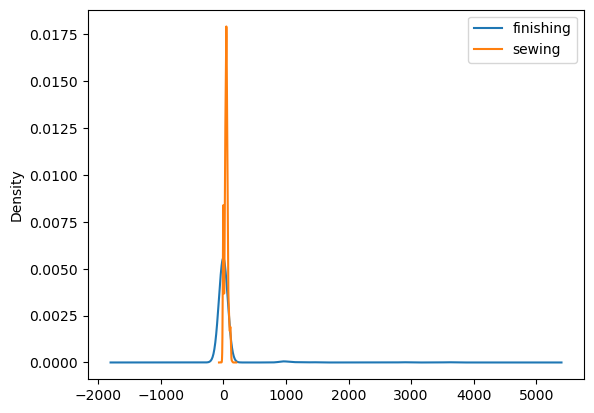

In [7]:
#Visualization of incentives based on department
garments.groupby(garments.department)['incentive'].plot(kind='kde',legend=True)

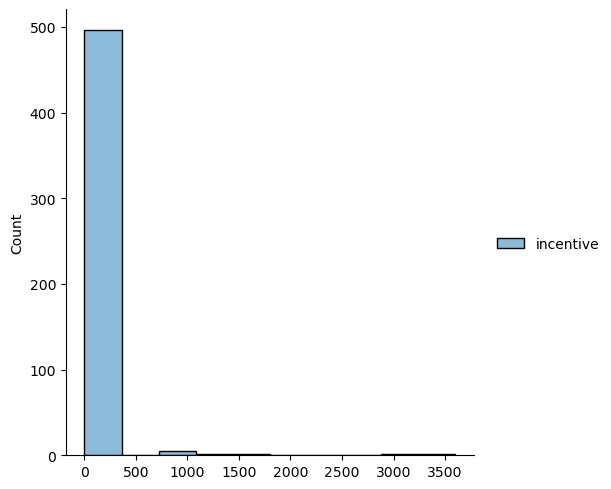

In [8]:
sns.displot(finishing_incentive)

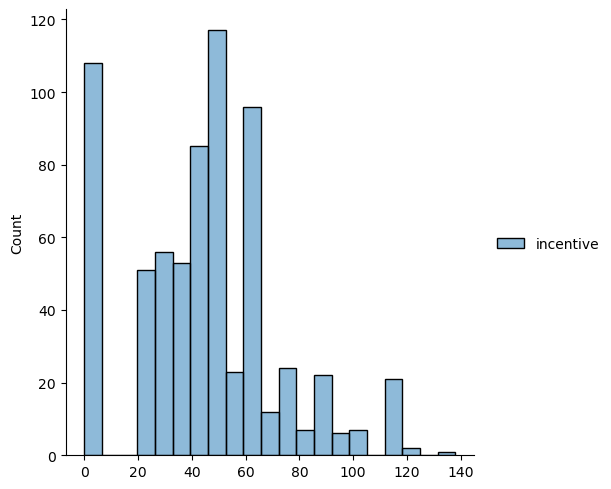

In [9]:
sns.displot(sewing_incentive)

In [ ]:
# perform the shapiro test:test for normality 
Assumptions: population data follows normal distribution
H0 : pop data = normal
H1 : pop data != normal

In [5]:
import scipy.stats as st
st.shapiro(garments.incentive)

ShapiroResult(statistic=0.1496147877432542, pvalue=1.6122624307524022e-58)

In [10]:
#shapiro conclusion
statitics,pvalue = st.shapiro(garments.incentive)
print(f"statitics",statitics)
print(f"pvalue",pvalue)
alpha=0.05
if pvalue < alpha:
    print("\n Reject H0.Incentive data  follows normal distribution")
else:
    print("Fail to Reject H1.Incentive data not follows normal distribution")

statitics 0.1496147877432542
pvalue 1.6122624307524022e-58

 Reject H0.Incentive data  follows normal distribution


In [ ]:
#equal variance test: levene test 
Assumptions: population have equal variances
H0 : pop1_variance != pop2_variance
H1 :  pop1_variance = pop2_variance

In [14]:
import scipy.stats as st 

f= garments[garments.department == 'finishing' ]['incentive']
s=garments[garments.department == 'sewing']['incentive']
st.levene(f,s)

LeveneResult(statistic=0.8816552660102075, pvalue=0.347938458912764)

In [16]:
#levene conclusion
statitics,pvalue = st.levene(f,s)
print(f"statitics",statitics)
print(f"pvalue",pvalue)
alpha=0.05
if pvalue < alpha:
    print("\n Reject H0.The finishing and sewing department variances are same")
else:
    print(" \n Fail to Reject H1.The finishing and sewing department variances are  not same")


statitics 0.8816552660102075
pvalue 0.347938458912764
 
 Fail to Reject H1.The finishing and sewing department variances are  not same


In [ ]:

#State null and alternate hypothesis
#whether the finishing department has achieved obtained higher incentive than sewing department
H0: finishing_dept_incentive > sewing_dept_incentive
H1: finishing_dept_incentive <= sewing_dept_incentive

In [ ]:
#State the alpha value ,default  value is 0.05
alpha = 0.05

In [20]:
#perform ttest
import scipy.stats as st
st.ttest_ind(f,s,alternative='greater')


TtestResult(statistic=-1.5842837176236164, pvalue=0.9433031231396383, df=1195.0)

In [22]:

#conclusion
dept_statitics,pvalue = st.ttest_ind(f,s,alternative='greater')
print("dept_statitics",dept_statitics)
print("pvalue",pvalue)
alpha=0.05
if pvalue < alpha:
    print("\n Reject H0.The finishing department has achieved  incentive  more than the  sewing department")
else:
    print(" \n Fail to Reject H1.The finishing department has achieved  incentive lesser than or equal  to  the sewing department")


dept_statitics -1.5842837176236164
pvalue 0.9433031231396383
 
 Fail to Reject H1.The finishing department has achieved  incentive lesser than or equal  to  the sewing department


# 16.The manager has asked you to classifiy low productivity as less than .5, medium between .5 and less than .75 and higher as greater than or equal to .75. He believes that the percentage of actual producvity in sewing departemnt for
# person classified as low is 30%, for medium is 40% and for high is 30%. USing chi square test can you prove whether his hypothesis is right or not

In [45]:
# Filter sewing department actual _productivity
sewingdata=garments[garments.department == 'sewing']['actual_productivity']

In [46]:
# Classify productivity levels
lowcount=sum(sewingdata < 0.5)
print("lowcount",lowcount)
mediumcount = sum((sewingdata >= 0.5) & (sewingdata <= 0.75))
print("mediumcount",mediumcount)
highcount= sum(sewingdata >=0.75)
print("highcount",highcount)
print("total",len(sewingdata))

lowcount 69
mediumcount 208
highcount 414
total 691


In [47]:
import scipy.stats as st 
from scipy.stats import chisquare


In [ ]:
#State  Null and Alternative Hypothesis
H0 :  observation != expected ("The observed productivity distribution in the sewing department does not match the manager's expected distribution")
H1 :  observation = expected ("The observed productivity distribution in the sewing department matches with the manager's expected distribution")

In [36]:
#Observed frequencies
observed = [low,medium,high]


In [37]:
#Total count in sewing department
total = len(sewingdata)


In [38]:
#Excepted frequencies based on manager's hypothesis 
expected = [ 0.3 * total ,0.4 * total ,0.3 * total]


In [39]:
#Perform chisquare goodness_of_fit test
st.chisquare(observed ,expected)

Power_divergenceResult(statistic=315.2952243125905, pvalue=3.4238281264112183e-69)

In [52]:
chi2stat, pvalue = chisquare(f_obs =observed ,f_exp=expected)


In [53]:
print(f"Chisquare Statistic :{chi2stat:}")
print(f"pvalue : {pvalue:}")

Chisquare Statistic :315.2952243125905
pvalue : 3.4238281264112183e-69


In [54]:
#Conclusion
alpha = 0.05 
if pvalue < alpha:
    print("Reject Null Hypothesis \n")
    print("The observed productivity distribution in the sewing department does not match the manager's expected distribution.")
else:
    print("Fail to Reject Null Hypothesis \n")
    print("The observed productivity distribution in the sewing department matches with the manager's expected distribution")

Reject Null Hypothesis 

The observed productivity distribution in the sewing department does not match the manager's expected distribution.


# 17.Based on the EDA analysis the manager has decided to find out whether different quarters are having an impact on actual productivity.
# Assuming normality of data conduct an analysis accordingly Conduct an ANOVA for comparing productivity for Quarter1, Quarter2, Quarter3, Quarter 4 
# and accordingly conclude (Assume data is normally distributed)

In [59]:
#Group actual_productivity based on quarters 
garments.groupby(garments.quarter )['actual_productivity'].describe()

,count,mean,std,min,25%,50%,75%,max
quarter,,,,,,,,
Quarter1,360.0,0.751560,0.161318,0.260979,0.699965,0.800045,0.850120,1.050667
Quarter2,335.0,0.743710,0.171114,0.233705,0.652280,0.800035,0.850502,1.100484
Quarter3,210.0,0.704759,0.175614,0.235795,0.613848,0.725436,0.800391,1.120437
Quarter4,248.0,0.709067,0.185983,0.259375,0.600431,0.750411,0.814431,1.059621
Quarter5,44.0,0.826177,0.183851,0.286985,0.750647,0.888276,0.971867,1.000457


In [60]:
#Extract the data for each quarters
Q1= garments[garments.quarter ==  'Quarter1' ]['actual_productivity']
print("days in Q1",len(Q1))
Q2= garments[garments.quarter ==  'Quarter2' ]['actual_productivity']
print("days in Q2",len(Q2))
Q3= garments[garments.quarter ==  'Quarter3' ]['actual_productivity']
print("days in Q3",len(Q3))
Q4= garments[garments.quarter ==  'Quarter4' ]['actual_productivity']
print("days in Q4",len(Q4))
#Neglecting quarter 5 
#q5= garments[garments.quarter ==  'Quarter5' ]['actual_productivity']
#print("days in q5",len(q5))

days in Q1 360
days in Q2 335
days in Q3 210
days in Q4 248


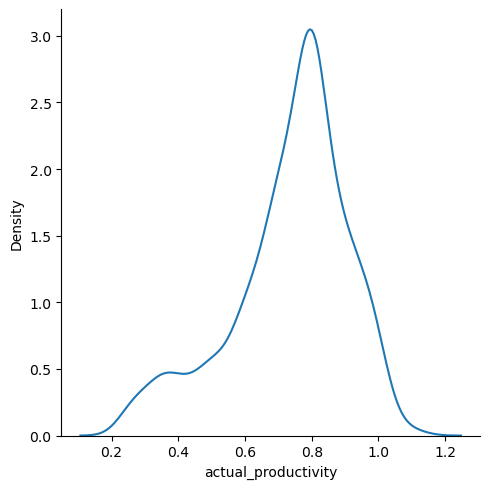

In [4]:
#Visualizing the distirbution for actualproductivity ,and it follows normal distribution
sns.displot(garments.actual_productivity,kind="kde")

In [ ]:

#Variance equality test 
#Assumptions:population has equal variance
H0: Pop1_var = Pop2_var ("The variances are different across all Quarters") 
H1 :Pop1_var != Pop2_var ("The variances are   not different across all Quarters") 



In [61]:
#Performing equality variance test
import scipy.stats as st
st.levene(Q1,Q2,Q3,Q4)

LeveneResult(statistic=2.235514108192818, pvalue=0.08246483203771338)

In [65]:
levenestats , pvalue =st.levene(Q1,Q2,Q3,Q4)
print(f"levene_statistics",levenestats)
print(f"levene_pvalue",pvalue)
# Levene Conclusion
alpha=0.05
if pvalue < alpha :
    print("Reject H0.The variances are  significantly different across all Quarters ")
else:
    print("Fail to reject H0.The variances are   not  significantly different across all Quarters")

levene_statistics 2.235514108192818
levene_pvalue 0.08246483203771338
Fail to reject H0.The variances are   not  significantly different across all Quarters


In [66]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm



In [ ]:
#Different quarters are having an impact on actual productivity.
#State Null and Alternate hypothesis
H0:  The  Mean actual_productivity for all quarters are  same
H1 : The Mean actual_productivity for one quarter is different



In [67]:
#Conduct One Way Annova 
st.f_oneway(Q1,Q2,Q3,Q4)

F_onewayResult(statistic=5.274463802636486, pvalue=0.0012927759459059219)

In [72]:
#Conclusion
fstatistics, pvalue =st.f_oneway(Q1,Q2,Q3,Q4)
print(f"fstatistics",fstatistics)
print(f"pvalue ",pvalue) 
alpha= 0.05
if pvalue < alpha:
    print(" \nReject Null Hypothesis\n")
    print( "The  Mean actual_productivity for all quarters are same")
else:
    print("Fail to Reject\n")
    print("The Mean actual_productivity for all quarters are  not same")


fstatistics 5.274463802636486
pvalue  0.0012927759459059219
 
Reject Null Hypothesis

The  Mean actual_productivity for all quarters are same


# 18.In case the manager is interested whether day and quarters have an impact on actual producitivity, provide an analysis and identify which factors play a role in affecting productivty

In [54]:
#Basic statistics of Actual productivity based on Day 
garments.groupby(garments.day)['actual_productivity'].describe()

,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Monday,199.0,0.735488,0.177330,0.246250,0.679583,0.795417,0.850137,1.059621
Saturday,187.0,0.751929,0.175980,0.238042,0.656924,0.800117,0.870332,1.050667
Sunday,203.0,0.728604,0.177595,0.235795,0.645046,0.750651,0.850391,1.120437
Thursday,199.0,0.722641,0.173503,0.233705,0.610362,0.750651,0.846279,1.100484
Tuesday,201.0,0.742701,0.163351,0.268214,0.681061,0.750797,0.850313,1.033570
Wednesday,208.0,0.730462,0.179237,0.247316,0.656615,0.783212,0.841858,1.050281


In [74]:
#Extract day wise productivity
thursday=garments[garments.day == 'Thursday']['actual_productivity']
saturday=garments[garments.day == 'Saturday']['actual_productivity']
sunday=garments[garments.day == 'Sunday']['actual_productivity']
monday=garments[garments.day == 'Monday']['actual_productivity']
tuesday=garments[garments.day == 'Tuesday']['actual_productivity']
wednesday = garments[garments.day == 'Wednesday']['actual_productivity']


day
Monday       Axes(0.125,0.11;0.775x0.77)
Saturday     Axes(0.125,0.11;0.775x0.77)
Sunday       Axes(0.125,0.11;0.775x0.77)
Thursday     Axes(0.125,0.11;0.775x0.77)
Tuesday      Axes(0.125,0.11;0.775x0.77)
Wednesday    Axes(0.125,0.11;0.775x0.77)
Name: actual_productivity, dtype: object

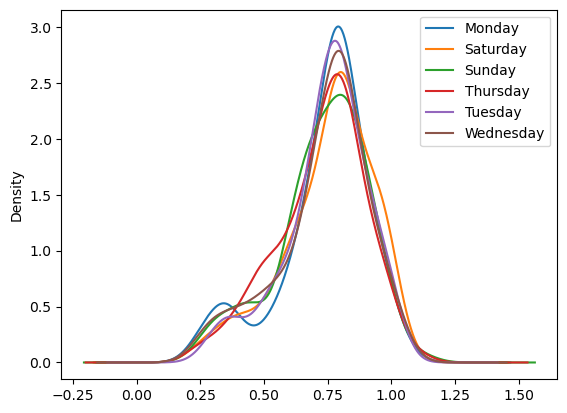

In [75]:
#Visualize Actualproductivity based on Day
garments.groupby(garments.day)['actual_productivity'].plot(kind='kde' , legend = True)

In [ ]:
#Day samples individually follows normal Distribution

In [ ]:
# Hence proceeding with equal variance test 
H0 : pop1_var = pop2_var (The Variances are equal across all days)
H1 : pop1_var != pop2_var (The Variances are  not equal accross all days)
st.levene(saturday,sunday,monday,tuesday,wednesday,thursday)

In [80]:
# levene test Conclusion
levene_statistics , pvalue = st.levene(saturday,sunday,monday,tuesday,wednesday,thursday)
print(f"levene_statistics",levene_statistics)
print(f"pvalue",pvalue)
alpha=0.05
if pvalue < alpha:
    print("Reject H0.The Variances are equal across all days")
else:
    print("Fail to reject H0.The Variances are  not equal accross all days")

levene_statistics 0.4284935320388341
pvalue 0.8289914795144732
Fail to reject H0.The Variances are  not equal accross all days


In [66]:
#since 'day' and 'quarter' both are categorical  proceeding with  chisquare test of association to check dependancy if any

In [67]:
#Cross_tabulation to explore Relationships among day and quarter if any  
pd.crosstab(garments.day,garments.quarter)

quarter,Quarter1,Quarter2,Quarter3,Quarter4,Quarter5
day,,,,,
Monday,61,63,37,38,0
Saturday,59,39,21,44,24
Sunday,60,64,38,41,0
Thursday,56,41,39,43,20
Tuesday,62,64,35,40,0
Wednesday,62,64,40,42,0


In [ ]:
#Contigency_table (chisquare test of independence) analysis
#State null and alternate hypothesis
H0: There is no association between two categorical variables quarter and day 
H1: There is an association between two categorical variables quarter and day

In [68]:
#Perform Contigency
st.chi2_contingency(pd.crosstab(garments.day,garments.quarter))

Chi2ContingencyResult(statistic=112.24402985523838, pvalue=7.641691672947457e-15, dof=20, expected_freq=array([[59.84962406, 55.69340017, 34.9122807 , 41.22974102,  7.31495405],
       [56.2406015 , 52.33500418, 32.80701754, 38.74352548,  6.87385129],
       [61.05263158, 56.8128655 , 35.61403509, 42.05847953,  7.4619883 ],
       [59.84962406, 55.69340017, 34.9122807 , 41.22974102,  7.31495405],
       [60.45112782, 56.25313283, 35.26315789, 41.64411028,  7.38847118],
       [62.55639098, 58.21219716, 36.49122807, 43.09440267,  7.64578112]]))

In [82]:
#chi2_contingency test conclusion
alpha=0.05
pvalue=7.641691672947457e-15
if pvalue < alpha :
    print("Reject H0.There is no association between Quarter and Day ")
else:
    print("Fail to reject H0.There is association between Quarter and Day ")


Reject H0.There is no association between Quarter and Day 


In [76]:
#ANOVA tables provide an estimate of how much variation in the dependent variable ( actual_productivity) is explained by the independent variable(day)
#Perform Annova for Day
m1= ols('actual_productivity~day', garments).fit()
anova_table1= anova_lm(m1)
anova_table1

,df,sum_sq,mean_sq,F,PR(>F)
day,5.0,0.108534,0.021707,0.712101,0.614379
Residual,1191.0,36.304916,0.030483,NaN,NaN


In [84]:
#Extract total variation for Day
total_variance_day=0.108534 + 36.304916
total_variance_day

36.41345

In [85]:
#Percentage of Variation Based on Day
((0.108534 / total_variance_day ) * 100)

0.2980601947906612

In [79]:
#ANOVA tables provide an estimate of how much variation in the dependent variable ( actual_productivity) is explained by the independent variable(quarter)
#Perform Annova for quarters
m2= ols('actual_productivity~quarter', garments).fit()
anova_table2= anova_lm(m2)
anova_table2

,df,sum_sq,mean_sq,F,PR(>F)
quarter,4.0,0.848747,0.212187,7.111735,0.000012
Residual,1192.0,35.564703,0.029836,NaN,NaN


In [86]:
#Extract total variation for  Quarter
total_variance_quarter=0.848747 + 35.564703
total_variance_quarter

36.413450000000005

In [87]:
#Percentage of Variation Based on  Quarter
(0.848747 / total_variance_quarter) * 100

2.330861261429499

In [ ]:
#Day contributes 29% impact on actualproductivity

# 19.Based on 17 eliminate one of the variabes which is not significant and reconduct analysis using deparment as another variable, what do you conclude.

In [ ]:

#taking department as another variable and reconducting analysis

department
finishing    Axes(0.125,0.11;0.775x0.77)
sewing       Axes(0.125,0.11;0.775x0.77)
Name: actual_productivity, dtype: object

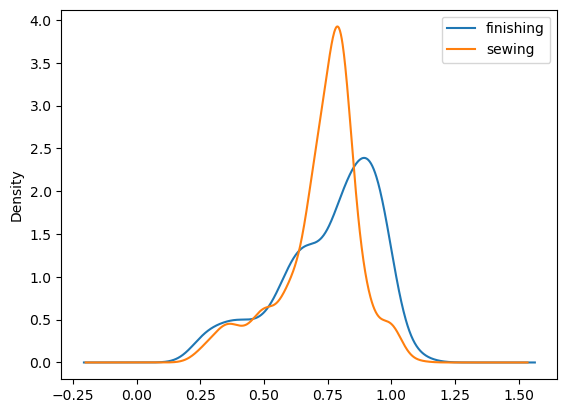

In [88]:
garments.groupby(garments.department)['actual_productivity'].plot(kind='kde',legend=True)

quarter
Quarter1    Axes(0.125,0.11;0.775x0.77)
Quarter2    Axes(0.125,0.11;0.775x0.77)
Quarter3    Axes(0.125,0.11;0.775x0.77)
Quarter4    Axes(0.125,0.11;0.775x0.77)
Quarter5    Axes(0.125,0.11;0.775x0.77)
Name: actual_productivity, dtype: object

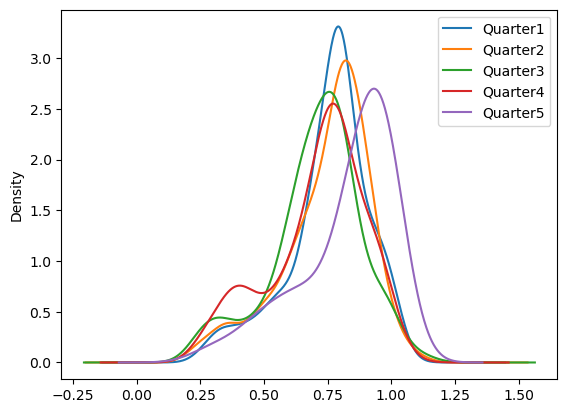

In [89]:
garments.groupby(garments.quarter )['actual_productivity'].plot(kind='kde',legend=True)

In [92]:
#Extract finishing_data
finishing_data=garments[garments.department=='finishing']['actual_productivity']
finishing_data

1       0.886500
6       0.755167
13      0.705917
14      0.676667
15      0.593056
          ...   
1192    0.628333
1193    0.625625
1194    0.625625
1195    0.505889
1196    0.394722
Name: actual_productivity, Length: 506, dtype: float64

In [95]:
#Extract sewing_data
sewing_data=garments[garments.department=='sewing']['actual_productivity']
sewing_data

0       0.940725
2       0.800570
3       0.800570
4       0.800382
5       0.800125
          ...   
1187    0.750051
1188    0.700557
1189    0.700505
1190    0.700246
1191    0.650596
Name: actual_productivity, Length: 691, dtype: float64

In [ ]:
#Perform levene Test
H0 :The Variances are same for  both the departments ( finishing and sewing)
H1 : The Variances are not same for both departments ( finishing and sewing)

In [96]:
st.levene(finishing_data,sewing_data)

LeveneResult(statistic=42.14213973141611, pvalue=1.241332081072637e-10)

In [105]:
#Levene conclusion
levene_statistics , pvalue = st.levene(finishing_data,sewing_data)
print(f"levene_statistics",{levene_statistics})
print(f"pvalue",{pvalue})
alpha=0.05
if pvalue < alpha:
    print(" \n Reject H0.The Variances are same for  both the departments ( finishing and sewing)")
else:
    print("Fail to reject H0,The Variances are not same for both departments ( finishing and sewing)")

levene_statistics {42.14213973141611}
pvalue {1.241332081072637e-10}
 
 Reject H0.The Variances are same for  both the departments ( finishing and sewing)


In [102]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm



In [ ]:
#Departments have   impact on actual productivity.
#State Null and Alternate hypothesis
H0:  The  Mean actual_productivity for both departments are same  
H1 : The Mean actual_productivity for both departments are not  same  

In [103]:
#Conduct One Way Annova 
st.f_oneway(finishing_data,sewing_data)

F_onewayResult(statistic=9.246175421332591, pvalue=0.002411259977623153)

In [109]:
#Conclusion
f_statistics , pvalue =st.f_oneway(finishing_data,sewing_data)
alpha=0.05
print(f"f_statistics",{f_statistics})
print(f"pvalue",{pvalue})
if pvalue < alpha:
    print(" \nReject Null Hypothesis\n")
    print( "The  Mean actual_productivity for both departments are same")
else:
    print("Fail to Reject\n")
    print("The Mean actual_productivity for both departments are not  same")


f_statistics {9.246175421332591}
pvalue {0.002411259977623153}
 
Reject Null Hypothesis

The  Mean actual_productivity for both departments are same


In [110]:
#Perform Annova
m3= ols('actual_productivity~department', garments).fit()
anova_table3= anova_lm(m3)
anova_table3

,df,sum_sq,mean_sq,F,PR(>F)
department,1.0,0.279582,0.279582,9.246175,0.002411
Residual,1195.0,36.133868,0.030238,NaN,NaN


In [112]:
#capture the total variance 
total_variance=0.279582 + 36.133868
total_variance

36.41345

In [114]:
#percentage  contribution of department in actual_production 
(0.279582 / total_variance ) * 100

0.7677987117397556

# 20. Based on EDA and Hypothesis would you aggree or disaggree with the finding, also in addition summarize the findings based on both analysis and provide a recommendation on what you can thinking on improving the producitivity.

 # conclusions and key findings

In [ ]:
#conclusion based on mean and standarddeviation:
1.The histogram depicts the  Actual productivity for Q3 and Q4  are almost same.
2.The Actual productivity for Q1 is little higher than that of Q2
3.Q5 claims the  maximum productivity among the Quarters
4.Q4 shows the maximum  standard deviation


In [ ]:
#conclusion based on department
1. The Finishing department has better productivity than sewing department
2. The Finishing department has more std dev than sewing department. This shows that the difference in max and min productivity in sewing department is lesser than in finishing department. 

In [ ]:
#conclusion based on days and team
1. More workers are showing same productivity (concentrated around .8) on Mondays than any other days.
2. More Workers are showing equally likely productivity on sundays(.7 to .85) and thursdays (.7 to .9)
3. Team 12 workers show similar productivity 
4. Team 9 and 10 have large number of high productive workers. 
5. Q5 is most productive 
6. Q1 - more number of workers show same productivity
7. Q2 - equal distribution of workers seen in the productivity range (.8 - .9)

In [ ]:
#Conclusions based on days
1. Less outliers on Thursday mean, maximum of the workers are showing similar productivity
2. Excluding the outliers on sunday, more workers are showing similar productivity distributed more or less equally in the range of 0.65 to 0.85
3. On mondays and tuesdays, lot of workers productivity is very less as they have lot of outliers
5. Thursdays show longtails as they are left skewed and has the minimum  outliers  
6. Sunday shows more productivity and is consistent

In [ ]:
#Conclusions based on teams
1. Team 5 and 11 have most workers with similar productivity with average productivity of around 0.7
2. Team  7 has no outliers the  productivity distribution seems symmetric 
3. Team12 has  more number of outliers on both sides and with productivity around 0.8 
4. Team 1,6 are negatively skewed
5. Team 3,9 are positively skewed

In [ ]:
#Conclusions based on quarter
1. Q3 has outliers on both sides with mean productivity of 0.7
2. Q1  is negatively skewed with outliers with mean productivity of 0.8
3. Q2 is negatively skewed with  outliers in the lower quartile with mean productivity of 0.8
4. Q4 has three outliers with mean productivity of 0.78
5. Q5 has least outliers with highest mean productivity 

In [ ]:
#conclusion based on target and actual productivity
1.The company is able to meet their target productivity and workers actualproductivity exceeds target 
2.Finishing department acheives its target and the productivity is more likely than sewing department
3.The average productivity shows in between 0.7 to 0.8

In [ ]:
#conclusion based on overtime
1.Overtime has effect on productivity for both departments
2.Sewing department seems to have worked for more time than finishing department in between 3000 to 10000
3.Finishing department has  worked in between 0 to 4000 which is comparetively lesser time than sewing 

# provide a recommendation on what you can thinking on improving the producitivity.

In [ ]:
1.Target based incentives will motivate the workers to bring more production
2.Finishing department should  be given more incentives at par to  sewing department 
3.Overtime incentives should be implemented for both departments